<a href="https://colab.research.google.com/github/reneta-dimitrova96/Deep-Learning-Course-Project-2026/blob/main/notebooks/03_Siamese_BiLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Siamese BiLSTM

## Notebook Objective

In this notebook, a Siamese BiLSTM model is built for the paraphrase detection task.

The two sentences are processed separately using a shared encoder, and their representations are compared to determine whether they have the same meaning.

The project uses the **PAWS-Wiki Labeled (Final)** dataset. The PAWS-Wiki dataset was released by Google Research and is used in this project for educational purposes. Google LLC (Google) is acknowledged as the data source.

### Sources

- [PAWS-Wiki Dataset on Hugging Face](https://huggingface.co/datasets/google-research-datasets/paws)
- [Official PAWS Repository by Google Research](https://github.com/google-research-datasets/paws)

## 1. Setup and Imports

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import (
    Input,
    TextVectorization,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Lambda
)

from tensorflow.keras.models import Model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Loading and Preparing the Dataset

The same dataset and cleaning steps from the previous notebooks are used here. The two sentences are kept separate because they will be processed by the two branches of the Siamese model.

In [ ]:
dataset = load_dataset(
    "google-research-datasets/paws",
    "labeled_final"
)

README.md:   0%|          | 0.00/9.79k [00:00<?, ?B/s]

labeled_final/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 8.43MB            

labeled_final/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

labeled_final/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 1.24MB            

labeled_final/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

labeled_final/validation-00000-of-00001.(…): reconstructing file:   0%|          |  0.00B / 1.23MB            

labeled_final/validation-00000-of-00001.(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/49401 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8000 [00:00<?, ? examples/s]

In [ ]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

### Data Cleaning

The same cleaning function is used to remove conflicting sentence pairs and keep only one occurrence of the remaining duplicates.

In [ ]:
def clean_sentence_pairs(df):
    pair_columns = ["sentence1", "sentence2"]

    conflicting_pairs = (
        df.groupby(pair_columns)["label"]
        .nunique()
        .reset_index()
    )

    conflicting_pairs = conflicting_pairs[
        conflicting_pairs["label"] > 1
    ]

    clean_df = df.merge(
        conflicting_pairs[pair_columns],
        on=pair_columns,
        how="left",
        indicator=True
    )

    clean_df = clean_df[
        clean_df["_merge"] == "left_only"
    ].drop(columns="_merge")

    clean_df = clean_df.drop_duplicates(
        subset=pair_columns
    ).reset_index(drop=True)

    return clean_df

In [ ]:
clean_train_df = clean_sentence_pairs(train_df)
clean_validation_df = clean_sentence_pairs(validation_df)
clean_test_df = clean_sentence_pairs(test_df)

print("Train:", clean_train_df.shape)
print("Validation:", clean_validation_df.shape)
print("Test:", clean_test_df.shape)

Train: (49334, 4)
Validation: (7994, 4)
Test: (7977, 4)


## 3. Text Vectorization

Before the sentences can be used by the neural network, the words need to be converted into integer sequences.

A shared vocabulary is created from both sentence columns in the training set. The same vectorizer will later be used for `sentence1` and `sentence2`.

In [ ]:
MAX_TOKENS = 20000
SEQUENCE_LENGTH = 40

In [ ]:
vectorizer = TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

In [ ]:
training_text = pd.concat([
    clean_train_df["sentence1"],
    clean_train_df["sentence2"]
])

In [ ]:
vectorizer.adapt(training_text)

In [ ]:
vocab_size = len(vectorizer.get_vocabulary())

print("Vocabulary size:", vocab_size)

Vocabulary size: 20000


In [ ]:
example_sentence = clean_train_df["sentence1"].iloc[0]

print("Original sentence:")
print(example_sentence)

print("\nVectorized sentence:")
print(vectorizer([example_sentence]).numpy()[0])

Original sentence:
In Paris , in October 1560 , he secretly met the English ambassador , Nicolas Throckmorton , asking him for a passport to return to England through Scotland .

Vectorized sentence:
[    3   546     3   126  6055    15  7571   529     2   219  1386  5793
  7405 10847   173    13     6  5432     9   668     9   181   213   507
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]


## 4. Preparing Model Inputs

The two sentences are vectorized separately because the Siamese model will process them through the same encoder. The labels are stored separately as the target values.

In [ ]:
X1_train = vectorizer(clean_train_df["sentence1"].values)
X2_train = vectorizer(clean_train_df["sentence2"].values)
y_train = clean_train_df["label"].values

X1_validation = vectorizer(clean_validation_df["sentence1"].values)
X2_validation = vectorizer(clean_validation_df["sentence2"].values)
y_validation = clean_validation_df["label"].values

X1_test = vectorizer(clean_test_df["sentence1"].values)
X2_test = vectorizer(clean_test_df["sentence2"].values)
y_test = clean_test_df["label"].values

In [ ]:
print("Train:", X1_train.shape, X2_train.shape, y_train.shape)
print("Validation:", X1_validation.shape, X2_validation.shape, y_validation.shape)
print("Test:", X1_test.shape, X2_test.shape, y_test.shape)

Train: (49334, 40) (49334, 40) (49334,)
Validation: (7994, 40) (7994, 40) (7994,)
Test: (7977, 40) (7977, 40) (7977,)


## 5. Building the Siamese BiLSTM Model

The model uses two inputs, one for each sentence. Both inputs are passed through the same encoder, so the two branches share the same weights.

The encoder contains an Embedding layer followed by a Bidirectional LSTM. The two sentence representations are then compared and used to predict whether the sentences are paraphrases.

In [ ]:
EMBEDDING_DIM = 128
LSTM_UNITS = 64

In [ ]:
encoder_input = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32"
)

embedded_sequence = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    mask_zero=True
)(encoder_input)

sentence_representation = Bidirectional(
    LSTM(LSTM_UNITS)
)(embedded_sequence)

encoder = Model(
    encoder_input,
    sentence_representation,
    name="shared_encoder"
)

In [ ]:
sentence1_input = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence1"
)

sentence2_input = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence2"
)

In [ ]:
encoded_sentence1 = encoder(sentence1_input)
encoded_sentence2 = encoder(sentence2_input)

In [ ]:
difference = Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1]),
    name="absolute_difference"
)([encoded_sentence1, encoded_sentence2])

In [ ]:
classification_features = Dense(
    64,
    activation="relu"
)(difference)

classification_features = Dropout(0.3)(
    classification_features
)

output = Dense(
    1,
    activation="sigmoid"
)(classification_features)

In [ ]:
siamese_model = Model(
    inputs=[
        sentence1_input,
        sentence2_input
    ],
    outputs=output,
    name="siamese_bilstm"
)

In [ ]:
siamese_model.summary()

Model: "siamese_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentence1           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentence2           │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder      │ (None, 128)       │  2,658,816 │ sentence1[0][0],  │
│ (Functional)        │                   │            │ sentence2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 128)       │          0 │ shared_encoder[0… │
│ (Lambda)            │                   │            │ shared_encoder[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ absolute_differe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,667,137 (10.17 MB)

 Trainable params: 2,667,137 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compiling and Training the Model

The Siamese BiLSTM model is compiled for binary classification and trained using the training sentence pairs.

The validation set is used during training to follow the model performance on unseen examples.

In [ ]:
siamese_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [ ]:
history = siamese_model.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=(
        [X1_validation, X2_validation],
        y_validation
    ),
    epochs=10,
    batch_size=64,
    callbacks=[early_stopping]
)

Epoch 1/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.7423 - loss: 0.5235 - val_accuracy: 0.7359 - val_loss: 0.5355
Epoch 2/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8783 - loss: 0.3182 - val_accuracy: 0.7534 - val_loss: 0.5608
Epoch 3/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9244 - loss: 0.2207 - val_accuracy: 0.7603 - val_loss: 0.5955


## 7. Training History

The training and validation metrics are plotted to see how the model performance changes across epochs and whether overfitting appears during training.

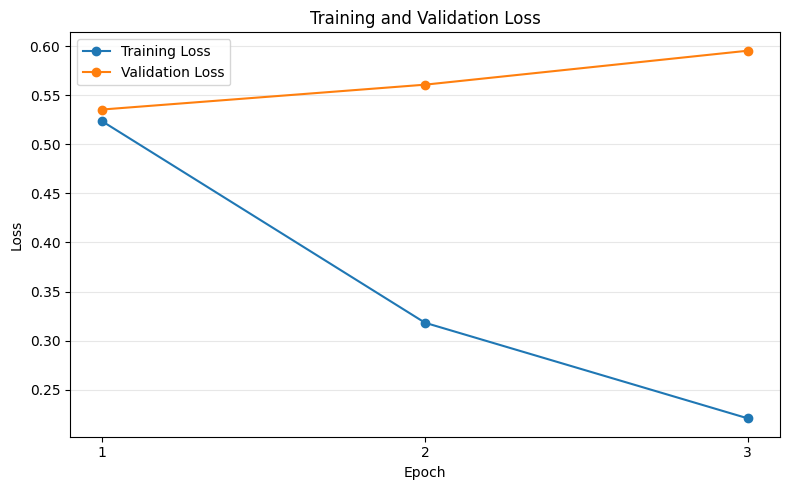

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.xticks(range(len(history.history["loss"])), range(1, len(history.history["loss"]) + 1))
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

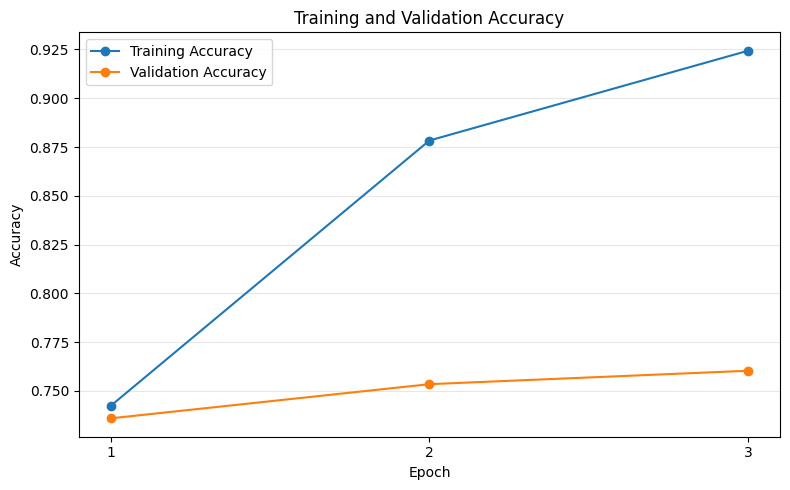

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.xticks(range(len(history.history["accuracy"])), range(1, len(history.history["accuracy"]) + 1))
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

The training loss decreases and the training accuracy increases quickly across the epochs. However, the validation loss starts increasing after the first epoch, while the validation accuracy improves only slightly.

This suggests that the model begins to overfit the training data. Early stopping prevents the training from continuing once the validation loss stops improving.

## 8. Validation Evaluation

The model is evaluated on the validation set using accuracy, precision, recall and F1-score.

In [ ]:
validation_probabilities = siamese_model.predict(
    [X1_validation, X2_validation],
    verbose=0
).ravel()

In [ ]:
y_validation_pred = (
    validation_probabilities >= 0.5
).astype(int)

In [ ]:
validation_accuracy = accuracy_score(
    y_validation,
    y_validation_pred
)

validation_precision = precision_score(
    y_validation,
    y_validation_pred
)

validation_recall = recall_score(
    y_validation,
    y_validation_pred
)

validation_f1 = f1_score(
    y_validation,
    y_validation_pred
)

print(f"Accuracy:  {validation_accuracy:.4f}")
print(f"Precision: {validation_precision:.4f}")
print(f"Recall:    {validation_recall:.4f}")
print(f"F1-score:  {validation_f1:.4f}")

Accuracy:  0.7359
Precision: 0.6634
Recall:    0.8175
F1-score:  0.7324


The validation results show that the Siamese BiLSTM performs much better than the baseline model (TF-IDF + Logistic Regression). The model has particularly high recall, which means that it is able to identify most of the paraphrase pairs.

The F1-score also shows a better balance between precision and recall, although there is still room for improvement.

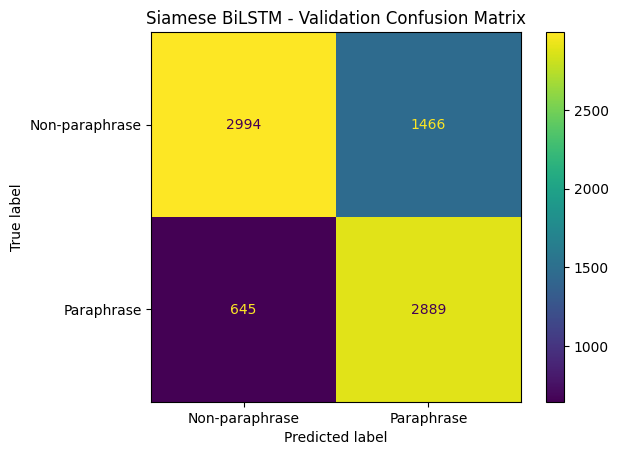

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    y_validation_pred,
    display_labels=["Non-paraphrase", "Paraphrase"]
)

plt.title("Siamese BiLSTM - Validation Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=["Non-paraphrase", "Paraphrase"]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.82      0.67      0.74      4460
    Paraphrase       0.66      0.82      0.73      3534

      accuracy                           0.74      7994
     macro avg       0.74      0.74      0.74      7994
  weighted avg       0.75      0.74      0.74      7994



The validation results are fairly balanced between the two classes. The model has higher recall for paraphrases and higher precision for non-paraphrases, while the F1-scores for both classes are very similar.

Overall, the Siamese BiLSTM performs considerably better than the baseline model (TF-IDF + Logistic Regression) on the validation set.

## 9. Improving the Siamese BiLSTM

The training history shows that the first Siamese BiLSTM starts to overfit after the first epoch. A second version of the model is created with a smaller embedding layer and stronger dropout to reduce overfitting.

The new model will be compared with the first version using the validation set.

In [ ]:
EMBEDDING_DIM_V2 = 64
LSTM_UNITS_V2 = 64

In [ ]:
encoder_input_v2 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32"
)

embedded_sequence_v2 = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM_V2,
    mask_zero=True
)(encoder_input_v2)

sentence_representation_v2 = Bidirectional(
    LSTM(
        LSTM_UNITS_V2,
        dropout=0.2
    )
)(embedded_sequence_v2)

encoder_v2 = Model(
    encoder_input_v2,
    sentence_representation_v2,
    name="shared_encoder_v2"
)

In [ ]:
sentence1_input_v2 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence1_v2"
)

sentence2_input_v2 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence2_v2"
)

encoded_sentence1_v2 = encoder_v2(sentence1_input_v2)
encoded_sentence2_v2 = encoder_v2(sentence2_input_v2)

In [ ]:
difference_v2 = Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1]),
    name="absolute_difference_v2"
)([encoded_sentence1_v2, encoded_sentence2_v2])

classification_features_v2 = Dense(
    32,
    activation="relu"
)(difference_v2)

classification_features_v2 = Dropout(0.4)(
    classification_features_v2
)

output_v2 = Dense(
    1,
    activation="sigmoid"
)(classification_features_v2)

In [ ]:
siamese_model_v2 = Model(
    inputs=[
        sentence1_input_v2,
        sentence2_input_v2
    ],
    outputs=output_v2,
    name="siamese_bilstm_v2"
)

siamese_model_v2.summary()

Model: "siamese_bilstm_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sentence1_v2        │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sentence2_v2        │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_encoder_v2   │ (None, 128)       │  1,346,048 │ sentence1_v2[0][… │
│ (Functional)        │                   │            │ sentence2_v2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_differenc… │ (None, 128)       │          0 │ shared_encoder_v… │
│ (Lambda)            │                   │            │ shared_encoder_v… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ absolute_differe… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,350,209 (5.15 MB)

 Trainable params: 1,350,209 (5.15 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
siamese_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping_v2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr_v2 = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
    verbose=1
)

In [ ]:
history_v2 = siamese_model_v2.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=(
        [X1_validation, X2_validation],
        y_validation
    ),
    epochs=10,
    batch_size=64,
    callbacks=[
        reduce_lr_v2,
        early_stopping_v2
    ]
)

Epoch 1/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.5833 - loss: 0.6523 - val_accuracy: 0.7047 - val_loss: 0.6085 - learning_rate: 5.0000e-04
Epoch 2/10
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.7843 - loss: 0.4859 - val_accuracy: 0.7047 - val_loss: 0.5763 - learning_rate: 5.0000e-04
Epoch 3/10
769/771 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8511 - loss: 0.3731
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8517 - loss: 0.3705 - val_accuracy: 0.6989 - val_loss: 0.6004 - learning_rate: 5.0000e-04
Epoch 4/10
770/771 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8888 - loss: 0.2979
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8884 - loss: 0.2966 - val_accuracy: 0.7130 - val_loss: 0.6237 - learning_rate: 2.5000e-04
Epoch 5/10
769/771 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy:

The second model reaches its lowest validation loss during the second epoch. After that, the training loss continues to decrease while the validation loss increases, which shows that overfitting is still present.

Reducing the learning rate does not lead to further improvement, and early stopping restores the weights from the best epoch.

In [ ]:
validation_probabilities_v2 = siamese_model_v2.predict(
    [X1_validation, X2_validation],
    verbose=0
).ravel()

y_validation_pred_v2 = (
    validation_probabilities_v2 >= 0.5
).astype(int)

In [ ]:
validation_accuracy_v2 = accuracy_score(
    y_validation,
    y_validation_pred_v2
)

validation_precision_v2 = precision_score(
    y_validation,
    y_validation_pred_v2
)

validation_recall_v2 = recall_score(
    y_validation,
    y_validation_pred_v2
)

validation_f1_v2 = f1_score(
    y_validation,
    y_validation_pred_v2
)

print(f"Accuracy:  {validation_accuracy_v2:.4f}")
print(f"Precision: {validation_precision_v2:.4f}")
print(f"Recall:    {validation_recall_v2:.4f}")
print(f"F1-score:  {validation_f1_v2:.4f}")

Accuracy:  0.7047
Precision: 0.6232
Recall:    0.8396
F1-score:  0.7154


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Siamese BiLSTM",
        "Siamese BiLSTM V2"
    ],
    "Accuracy": [
        validation_accuracy,
        validation_accuracy_v2
    ],
    "Precision": [
        validation_precision,
        validation_precision_v2
    ],
    "Recall": [
        validation_recall,
        validation_recall_v2
    ],
    "F1-score": [
        validation_f1,
        validation_f1_v2
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Siamese BiLSTM,0.735927,0.663375,0.817487,0.732412
1,Siamese BiLSTM V2,0.704653,0.623188,0.839559,0.715371


The second version achieves slightly higher recall, but its accuracy, precision and F1-score are lower than those of the first model. The additional regularization did not improve the overall validation performance, so another model will be tested with different hyperparameter settings.

### 9.1 Hyperparameter Tuning with Optuna

The first two Siamese BiLSTM models used manually selected hyperparameters. In this step, Optuna is used to test different combinations of model settings and find a better configuration.

The validation F1-score is used as the optimization metric because it provides a balance between precision and recall.

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.5 MB/s eta 0:00:00


In [ ]:
import optuna

In [ ]:
def build_siamese_model(
    embedding_dim,
    lstm_units,
    dense_units,
    dropout_rate,
    learning_rate
):
    encoder_input = Input(
        shape=(SEQUENCE_LENGTH,),
        dtype="int32"
    )

    embedded_sequence = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        mask_zero=True
    )(encoder_input)

    sentence_representation = Bidirectional(
        LSTM(
            lstm_units,
            dropout=dropout_rate
        )
    )(embedded_sequence)

    encoder = Model(
        encoder_input,
        sentence_representation
    )

    sentence1_input = Input(
        shape=(SEQUENCE_LENGTH,),
        dtype="int32"
    )

    sentence2_input = Input(
        shape=(SEQUENCE_LENGTH,),
        dtype="int32"
    )

    encoded_sentence1 = encoder(sentence1_input)
    encoded_sentence2 = encoder(sentence2_input)

    difference = Lambda(
        lambda tensors: tf.abs(
            tensors[0] - tensors[1]
        )
    )([
        encoded_sentence1,
        encoded_sentence2
    ])

    classification_features = Dense(
        dense_units,
        activation="relu"
    )(difference)

    classification_features = Dropout(
        dropout_rate
    )(classification_features)

    output = Dense(
        1,
        activation="sigmoid"
    )(classification_features)

    model = Model(
        inputs=[
            sentence1_input,
            sentence2_input
        ],
        outputs=output
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
def objective(trial):
    tf.keras.backend.clear_session()

    embedding_dim = trial.suggest_categorical(
        "embedding_dim",
        [64, 96, 128]
    )

    lstm_units = trial.suggest_categorical(
        "lstm_units",
        [32, 64, 96]
    )

    dense_units = trial.suggest_categorical(
        "dense_units",
        [32, 64]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.2,
        0.5,
        step=0.1
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-3,
        log=True
    )

    model = build_siamese_model(
        embedding_dim,
        lstm_units,
        dense_units,
        dropout_rate,
        learning_rate
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    )

    model.fit(
        [X1_train, X2_train],
        y_train,
        validation_data=(
            [X1_validation, X2_validation],
            y_validation
        ),
        epochs=8,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=0
    )

    validation_probabilities = model.predict(
        [X1_validation, X2_validation],
        verbose=0
    ).ravel()

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    return f1_score(
        y_validation,
        validation_predictions
    )

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(
        seed=42
    )
)

[I 2026-08-19 11:16:18,259] A new study created in memory with name: no-name-f9ae59f6-afce-4273-a30a-ae8b1af7741b


In [ ]:
study.optimize(
    objective,
    n_trials=10
)

[I 2026-08-19 11:17:53,635] Trial 0 finished with value: 0.7035305120411504 and parameters: {'embedding_dim': 96, 'lstm_units': 32, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.0005105903209394755}. Best is trial 0 with value: 0.7035305120411504.
[I 2026-08-19 11:19:08,098] Trial 1 finished with value: 0.6914084666893656 and parameters: {'embedding_dim': 96, 'lstm_units': 32, 'dense_units': 64, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00019553708662745247}. Best is trial 0 with value: 0.7035305120411504.
[I 2026-08-19 11:21:06,363] Trial 2 finished with value: 0.6845324140998554 and parameters: {'embedding_dim': 64, 'lstm_units': 96, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.00011128853174905746}. Best is trial 0 with value: 0.7035305120411504.
[I 2026-08-19 11:22:14,319] Trial 3 finished with value: 0.6930533117932148 and parameters: {'embedding_dim': 64, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.00027551

In [ ]:
print(
    f"Best validation F1-score: "
    f"{study.best_value:.4f}"
)

print("\nBest hyperparameters:")

for parameter, value in study.best_params.items():
    print(f"{parameter}: {value}")

Best validation F1-score: 0.7202

Best hyperparameters:
embedding_dim: 128
lstm_units: 96
dense_units: 64
dropout_rate: 0.2
learning_rate: 0.0009702573394120733


In [ ]:
trials_df = study.trials_dataframe()

trials_df[
    [
        "number",
        "value",
        "params_embedding_dim",
        "params_lstm_units",
        "params_dense_units",
        "params_dropout_rate",
        "params_learning_rate"
    ]
].sort_values(
    by="value",
    ascending=False
)

,number,value,params_embedding_dim,params_lstm_units,params_dense_units,params_dropout_rate,params_learning_rate
6,6,0.720200,128,96,64,0.2,0.000970
0,0,0.703531,96,32,64,0.4,0.000511
9,9,0.703371,128,64,32,0.2,0.000128
4,4,0.700492,96,32,64,0.4,0.000153
5,5,0.694541,64,96,64,0.2,0.000212
3,3,0.693053,64,64,32,0.4,0.000276
8,8,0.691421,64,96,32,0.5,0.000297
1,1,0.691408,96,32,64,0.3,0.000196
7,7,0.689608,64,32,32,0.3,0.000131
2,2,0.684532,64,96,64,0.4,0.000111


The best Optuna trial achieved a validation F1-score of 0.7202. This is slightly better than the second model, but it does not improve on the original Siamese BiLSTM.

The selected hyperparameters suggest that a larger model with lower dropout performs better than the more strongly regularized second version.

### 9.2 Siamese BiLSTM V3

The best hyperparameters found by Optuna are used to build and train a third version of the Siamese BiLSTM model.

This model will be evaluated on the validation set and compared with the previous two versions.

In [ ]:
best_params = study.best_params

siamese_model_v3 = build_siamese_model(
    embedding_dim=best_params["embedding_dim"],
    lstm_units=best_params["lstm_units"],
    dense_units=best_params["dense_units"],
    dropout_rate=best_params["dropout_rate"],
    learning_rate=best_params["learning_rate"]
)

In [ ]:
early_stopping_v3 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_v3 = siamese_model_v3.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=(
        [X1_validation, X2_validation],
        y_validation
    ),
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping_v3]
)

Epoch 1/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.6871 - loss: 0.5780 - val_accuracy: 0.6941 - val_loss: 0.5813
Epoch 2/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8471 - loss: 0.3713 - val_accuracy: 0.7352 - val_loss: 0.5775
Epoch 3/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8997 - loss: 0.2661 - val_accuracy: 0.7384 - val_loss: 0.5983
Epoch 4/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9295 - loss: 0.2034 - val_accuracy: 0.7426 - val_loss: 0.6504


In [ ]:
validation_probabilities_v3 = siamese_model_v3.predict(
    [X1_validation, X2_validation],
    verbose=0
).ravel()

y_validation_pred_v3 = (
    validation_probabilities_v3 >= 0.5
).astype(int)

In [ ]:
validation_accuracy_v3 = accuracy_score(
    y_validation,
    y_validation_pred_v3
)

validation_precision_v3 = precision_score(
    y_validation,
    y_validation_pred_v3
)

validation_recall_v3 = recall_score(
    y_validation,
    y_validation_pred_v3
)

validation_f1_v3 = f1_score(
    y_validation,
    y_validation_pred_v3
)

print(f"Accuracy:  {validation_accuracy_v3:.4f}")
print(f"Precision: {validation_precision_v3:.4f}")
print(f"Recall:    {validation_recall_v3:.4f}")
print(f"F1-score:  {validation_f1_v3:.4f}")

Accuracy:  0.7352
Precision: 0.6674
Recall:    0.7994
F1-score:  0.7274


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Siamese BiLSTM",
        "Siamese BiLSTM V2",
        "Siamese BiLSTM V3"
    ],
    "Accuracy": [
        validation_accuracy,
        validation_accuracy_v2,
        validation_accuracy_v3
    ],
    "Precision": [
        validation_precision,
        validation_precision_v2,
        validation_precision_v3
    ],
    "Recall": [
        validation_recall,
        validation_recall_v2,
        validation_recall_v3
    ],
    "F1-score": [
        validation_f1,
        validation_f1_v2,
        validation_f1_v3
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Siamese BiLSTM,0.735927,0.663375,0.817487,0.732412
1,Siamese BiLSTM V2,0.704653,0.623188,0.839559,0.715371
2,Siamese BiLSTM V3,0.735176,0.667375,0.799377,0.727437


The training history shows signs of overfitting, as the training performance continues to improve while the validation loss starts to increase.

A smaller and more regularized version was tested, but it did not improve the validation results. This suggests that reducing the model capacity too much may also limit its ability to learn useful sentence representations.

### 9.3 Siamese BiLSTM V4 with L2 Regularization

The previous models still showed signs of overfitting. In this experiment, the original model architecture is kept, but L2 regularization is added to reduce the growth of large weights during training.

The goal is to check whether this can improve the validation performance without reducing the model capacity.

In [ ]:
L2_RATE = 1e-4

encoder_input_v4 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32"
)

embedded_sequence_v4 = Embedding(
    input_dim=vocab_size,
    output_dim=128,
    mask_zero=True
)(encoder_input_v4)

sentence_representation_v4 = Bidirectional(
    LSTM(
        64,
        kernel_regularizer=tf.keras.regularizers.l2(L2_RATE)
    )
)(embedded_sequence_v4)

encoder_v4 = Model(
    encoder_input_v4,
    sentence_representation_v4,
    name="shared_encoder_v4"
)

sentence1_input_v4 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence1_v4"
)

sentence2_input_v4 = Input(
    shape=(SEQUENCE_LENGTH,),
    dtype="int32",
    name="sentence2_v4"
)

encoded_sentence1_v4 = encoder_v4(sentence1_input_v4)
encoded_sentence2_v4 = encoder_v4(sentence2_input_v4)

difference_v4 = Lambda(
    lambda tensors: tf.abs(tensors[0] - tensors[1])
)([encoded_sentence1_v4, encoded_sentence2_v4])

classification_features_v4 = Dense(
    64,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(L2_RATE)
)(difference_v4)

classification_features_v4 = Dropout(0.3)(
    classification_features_v4
)

output_v4 = Dense(
    1,
    activation="sigmoid"
)(classification_features_v4)

siamese_model_v4 = Model(
    inputs=[
        sentence1_input_v4,
        sentence2_input_v4
    ],
    outputs=output_v4,
    name="siamese_bilstm_v4"
)

In [ ]:
siamese_model_v4.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping_v4 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history_v4 = siamese_model_v4.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=(
        [X1_validation, X2_validation],
        y_validation
    ),
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping_v4]
)

Epoch 1/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7373 - loss: 0.5471 - val_accuracy: 0.7219 - val_loss: 0.5622
Epoch 2/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8706 - loss: 0.3484 - val_accuracy: 0.7378 - val_loss: 0.5763
Epoch 3/8
771/771 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.9154 - loss: 0.2559 - val_accuracy: 0.7501 - val_loss: 0.5995


In [ ]:
validation_probabilities_v4 = siamese_model_v4.predict(
    [X1_validation, X2_validation],
    verbose=0
).ravel()

y_validation_pred_v4 = (
    validation_probabilities_v4 >= 0.5
).astype(int)

validation_accuracy_v4 = accuracy_score(
    y_validation,
    y_validation_pred_v4
)

validation_precision_v4 = precision_score(
    y_validation,
    y_validation_pred_v4
)

validation_recall_v4 = recall_score(
    y_validation,
    y_validation_pred_v4
)

validation_f1_v4 = f1_score(
    y_validation,
    y_validation_pred_v4
)

print(f"Accuracy:  {validation_accuracy_v4:.4f}")
print(f"Precision: {validation_precision_v4:.4f}")
print(f"Recall:    {validation_recall_v4:.4f}")
print(f"F1-score:  {validation_f1_v4:.4f}")

Accuracy:  0.7219
Precision: 0.6427
Recall:    0.8353
F1-score:  0.7265


The L2-regularized model still shows signs of overfitting, as the training performance continues to improve while the validation loss increases after the first epoch.

The model achieves higher recall than the original version, but its accuracy, precision and F1-score are lower. Therefore, L2 regularization did not improve the overall validation performance.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Siamese BiLSTM",
        "Siamese BiLSTM V2",
        "Siamese BiLSTM V3",
        "Siamese BiLSTM V4"
    ],
    "Accuracy": [
        validation_accuracy,
        validation_accuracy_v2,
        validation_accuracy_v3,
        validation_accuracy_v4
    ],
    "Precision": [
        validation_precision,
        validation_precision_v2,
        validation_precision_v3,
        validation_precision_v4
    ],
    "Recall": [
        validation_recall,
        validation_recall_v2,
        validation_recall_v3,
        validation_recall_v4
    ],
    "F1-score": [
        validation_f1,
        validation_f1_v2,
        validation_f1_v3,
        validation_f1_v4
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Siamese BiLSTM,0.7359,0.6634,0.8175,0.7324
1,Siamese BiLSTM V2,0.7047,0.6232,0.8396,0.7154
2,Siamese BiLSTM V3,0.7352,0.6674,0.7994,0.7274
3,Siamese BiLSTM V4,0.7219,0.6427,0.8353,0.7265


The four models were compared using the validation set. Some of the newer versions achieved better precision or recall, but the original model still had the best F1-score.

For this reason, the original Siamese BiLSTM is selected as the final model.

## 10. Final Evaluation on the Test Set

The selected Siamese BiLSTM model is evaluated on the test set to measure its final performance on unseen data.

In [ ]:
test_probabilities = siamese_model.predict(
    [X1_test, X2_test],
    verbose=0
).ravel()

y_test_pred = (
    test_probabilities >= 0.5
).astype(int)

In [ ]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-score:  {test_f1:.4f}")

Accuracy:  0.7418
Precision: 0.6758
Recall:    0.7975
F1-score:  0.7316


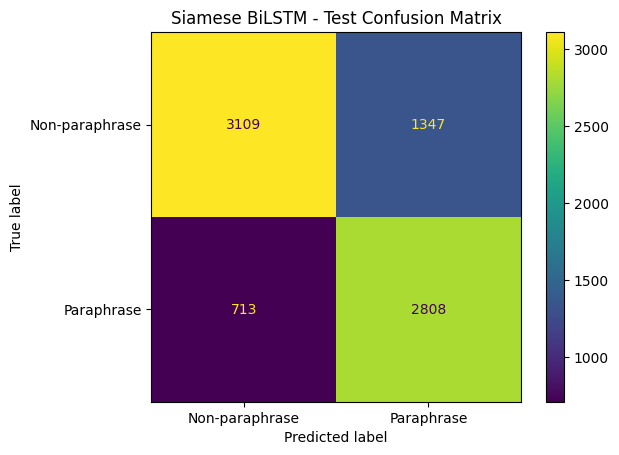

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=[
        "Non-paraphrase",
        "Paraphrase"
    ]
)

plt.title("Siamese BiLSTM - Test Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Non-paraphrase",
            "Paraphrase"
        ]
    )
)

                precision    recall  f1-score   support

Non-paraphrase       0.81      0.70      0.75      4456
    Paraphrase       0.68      0.80      0.73      3521

      accuracy                           0.74      7977
     macro avg       0.74      0.75      0.74      7977
  weighted avg       0.75      0.74      0.74      7977



In [ ]:
final_model_results = pd.DataFrame({
    "Dataset": [
        "Validation",
        "Test"
    ],
    "Accuracy": [
        validation_accuracy,
        test_accuracy
    ],
    "Precision": [
        validation_precision,
        test_precision
    ],
    "Recall": [
        validation_recall,
        test_recall
    ],
    "F1-score": [
        validation_f1,
        test_f1
    ]
})

final_model_results.round(4)

,Dataset,Accuracy,Precision,Recall,F1-score
0,Validation,0.7359,0.6634,0.8175,0.7324
1,Test,0.7418,0.6758,0.7975,0.7316


The validation and test results are very similar. The test set has slightly higher accuracy and precision, while recall is slightly lower.

The F1-score remains almost unchanged, which shows that the selected model performs consistently on unseen data.

## 11. Final Summary

The main findings from this notebook are:

- A Siamese BiLSTM model was built using a shared encoder for both sentences.
- The first model showed signs of high variance and overfitting during training.
- Several additional versions were tested using stronger regularization, Optuna hyperparameter tuning and L2 regularization.
- None of the later versions achieved a higher validation F1-score than the original model.
- The original Siamese BiLSTM was selected as the final model based on the validation results.
- The validation and test results were very similar, with a final test F1-score of 0.7316.

Overall, the Siamese BiLSTM performed considerably better than the TF-IDF + Logistic Regression baseline.